# Identifying Low Gym Traffic Using Stochastic Gradient Descent

## Introduction 

This project aims to use the dataset `crowdedness_gym_data.csv`, a synthetic dataset designed to simulate observed attendance patterns in college/univeristy campus gyms, to identify periods of low gym traffic. The dataset contains over 60,000 observations containing information on how many individuals were at a gym on a particular day and time. 

Due to the relatively large number of observations, stochastic gradient descent is to be used to search for a global minimum to identify dates/times where the number of gym-goers is at the lowest. This has practical application, which may help an individual decide when to visit the gym. 

### Data Dictionary
| Column               | Description                                                                                             |
|----------------------|---------------------------------------------------------------------------------------------------------|
| number_people        | the number of people at the gym at each observation (target variable)                                   |
| date                 | a string value with the specific date and time information.                                             |
| timestamp            | an integer representing the number of seconds since the start of the day.                               |
| day_of_week          | an integer. 0 is equal to Monday and 6 is equal to Sunday.                                              |
| is_weekend           | a Boolean value defining if this observation happened during a weekend. 1 = yes, 0 = no.                |
| is_holiday           | a Boolean value defining if the observation happened during a holiday. 1 = yes, 0 = no.                 |
| temperature          | a float, defining the temperature during the day of the observation in Fahrenheit.                      |
| is_start_of_semester | a Boolean defining if the observation happened in the first 2 weeks of a semester. 1 = yes, 0 = no.     |
| is_during_semester   | a Boolean defining if the observation happened during the active semester. 1 = yes, 0 = no.             |
| month                | an integer defining the month of the year. 1 is equal to January, 12 is equal to December.              |
| hour                 | an integer for the hour of the day from 0 to 23.                                                        |

## Importing Libraries and Loading the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline 

gym_data = pd.read_csv('crowdedness_gym_data.csv')

gym_data.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


## EDA

In [2]:
gym_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  str    
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), str(1)
memory usage: 5.2 MB


In [3]:
nulls = gym_data.isnull().sum()
nulls

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

No missing data.

The `date` column is redundant as there are other columns (such as `month` and `hour`) which capture information described by this column. As a result, we can drop this from the dataset.

In [4]:
gym_data.drop(columns=['date'], inplace=True)
gym_data.head()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,61211,4,0,0,71.76,0,0,8,17
1,45,62414,4,0,0,71.76,0,0,8,17
2,40,63015,4,0,0,71.76,0,0,8,17
3,44,63616,4,0,0,71.76,0,0,8,17
4,45,64217,4,0,0,71.76,0,0,8,17


In [5]:
print("Before dropping duplicates:", gym_data.shape[0])
gym_data.drop_duplicates(inplace=True)
print("After dropping duplicates:", gym_data.shape[0])

Before dropping duplicates: 62184
After dropping duplicates: 62184


No duplicates observations.

In [6]:
gym_data.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


There are no extreme values contained within any of the columns and the range of values within each column seem realistic.

### Distribution Visualization

To gain an idea about the distribution of each variable, histograms and bar charts can be plotted for each variable.

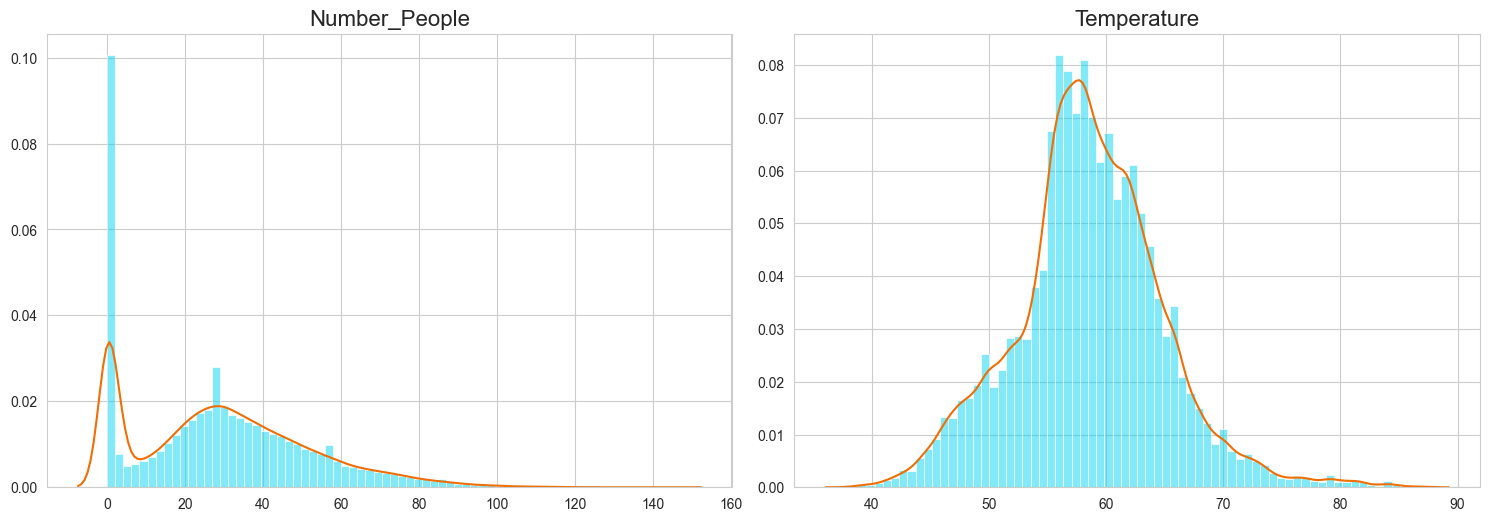

In [7]:
hist_plots = [
    "number_people",
    "temperature"
    ]

plt.figure(figsize=(15, 10))

for i, col in enumerate(hist_plots):
    plt.subplot(2, 2, i+1)
    sns.histplot(gym_data[col], color="#04d4f0", alpha=0.5, bins=70, stat="density") # stat="density" to show the density instead of count
    sns.kdeplot(gym_data[col], color="#f06e04")
    plt.title(f"{col.title()}", fontsize=16)
    plt.xlabel("")
    plt.ylabel("")
    
plt.tight_layout()
plt.show()

The `number_people` and `temperature` variables are approximately normally distributed. We also see that approximately 10% of observations have two or fewer people in the gym.

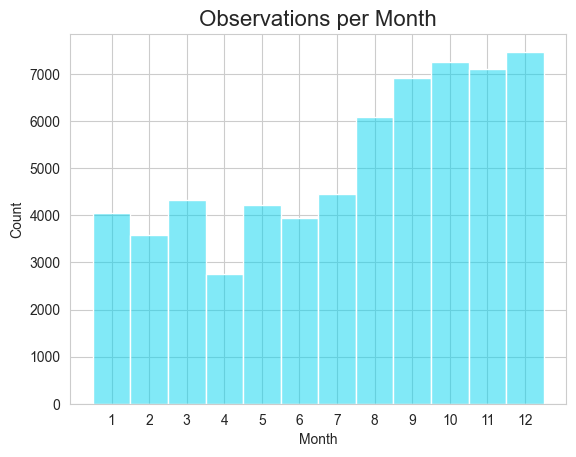

In [8]:
# Use explicit bin edges so that each month has its own bar (1-12 inclusive)
sns.histplot(gym_data['month'], color="#04d4f0", bins=range(1, 14), discrete=True, alpha=0.5)
plt.title("Observations per Month", fontsize=16)
plt.xlabel("Month")
plt.xticks(range(1, 13))
plt.show()

We can see the number of observations are at their peak in December, likely because this month is the most popular month to go to the gym. There is an apparent increase in the number of observations from July to August (which coincides with the beginning of the US college semester). The number of observations are the greatest during this first semester.

Moving into the second semester, the number of observations are far lower, falling to a minimum in April (this is likely because students become busy studying for exams), before slightly rebounding in May at the end of the semester. 

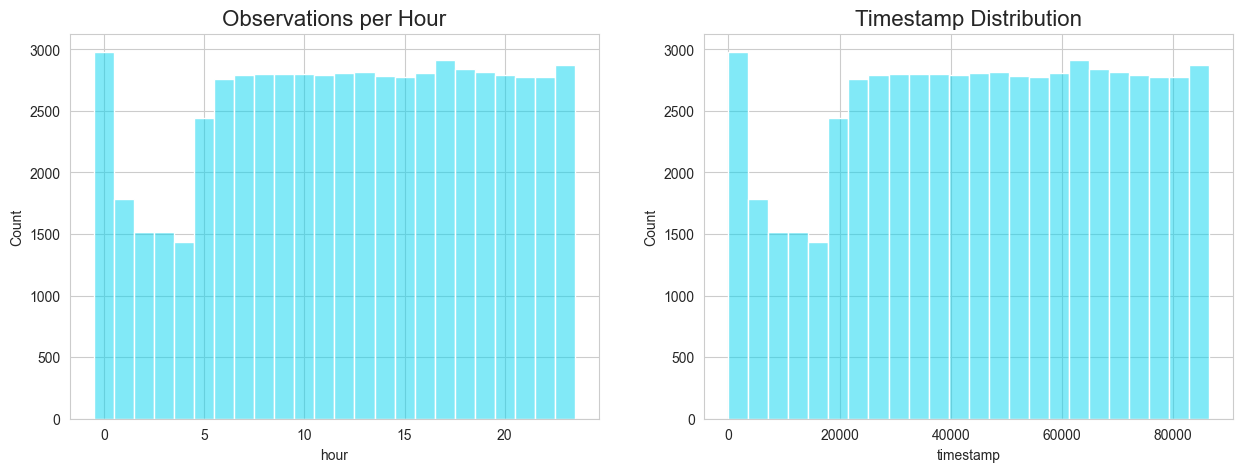

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(gym_data['hour'], color="#04d4f0", bins=range(1, 25), discrete=True, alpha=0.5)
plt.title("Observations per Hour", fontsize=16)

plt.subplot(1, 2, 2)
sns.histplot(gym_data['timestamp'], color="#04d4f0", bins=24, alpha=0.5)
plt.title("Timestamp Distribution", fontsize=16)

plt.show()

Turning to the `hour` and `timestamp` distributions, we see the timestamp distribution is redundant and can be entirely described using the `hour` variable. 

The number of observations are roughly uniform, falling to a minimum during the early hours of the morning (1am-4am).

---
The categorical variables are visualized below using bar charts.

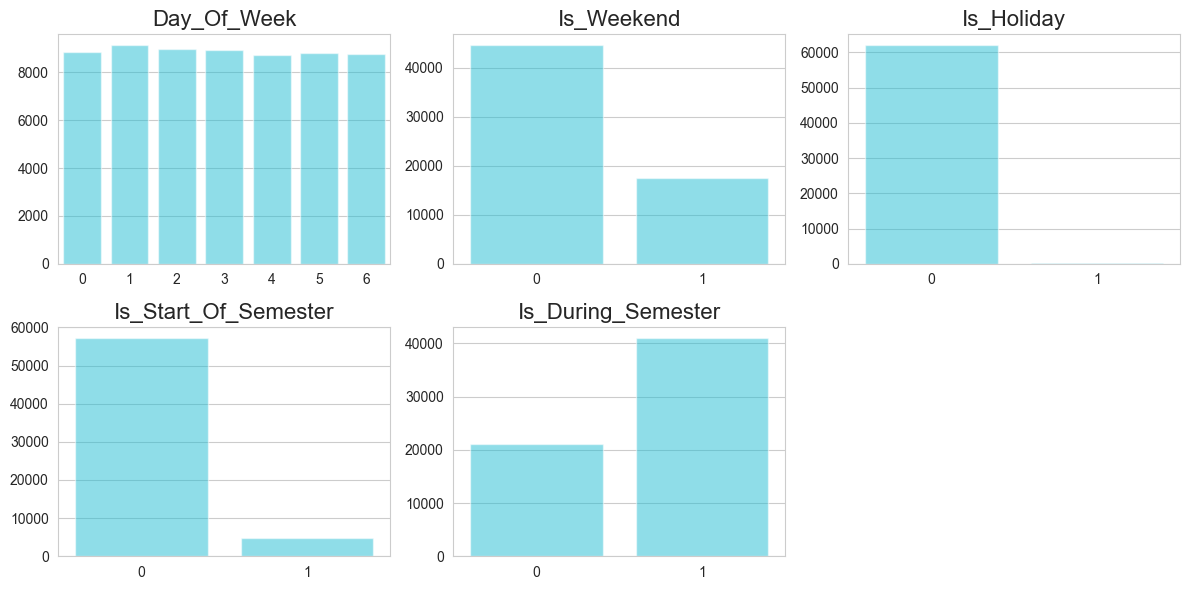

In [10]:
count_plots = [
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "is_start_of_semester",
    "is_during_semester"
    ]

plt.figure(figsize=(12, 6))

for i, col in enumerate(count_plots):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=gym_data[col], color="#04d4f0", alpha=0.5)
    plt.title(f"{col.title()}", fontsize=16)
    plt.xlabel("")
    plt.ylabel("")
    
plt.tight_layout()
plt.show()

We see the number of observations by day of the week is roughly uniform. There is a slight increase on Tuesday, but this does not seem to be significant.

The distributions of the remaining boolean variables does not really provide any additional information, except that the distributions are expected.

## Feature Selection

To aid in feature selection for the model, the correlation between each variable and the target variable `number_people` will be studied. For the numerical variables, Pearson's r will be used for its simplicity. Although this fails to capture any non-linear relationships, it is better than nothing.

For categorical variables, Cramér's V will be used to assess the strength of any relationships between each explanatory variable and the target variable.

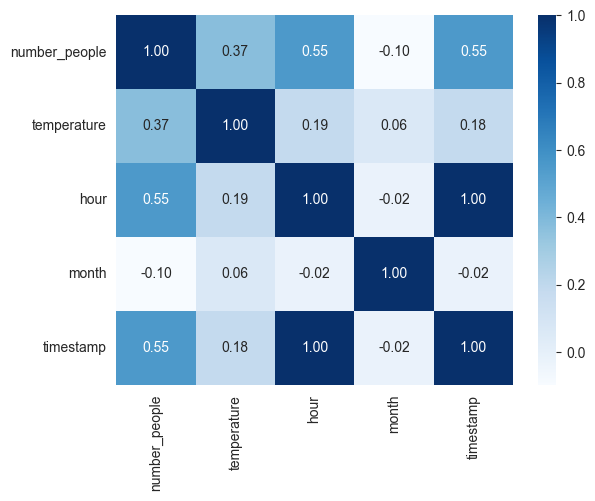

In [11]:
numerical_cols = ["number_people", "temperature", "hour", "month", "timestamp"]

sns.heatmap(gym_data[numerical_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.show()

The following numerical variables have the strongest linear relationship with the target variable:

* `hour`

* `timestamp`

* `temperature`

It is important to note that hour and timestamp are essentially describing the same information in different ways. Since `hour` is more straightforward to work with and interpret, we do not need to consider the `timestamp` variable.

In [12]:
gym_data.drop(columns=['timestamp'], inplace=True)
gym_data.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,4,0,0,71.76,0,0,8,17
1,45,4,0,0,71.76,0,0,8,17
2,40,4,0,0,71.76,0,0,8,17
3,44,4,0,0,71.76,0,0,8,17
4,45,4,0,0,71.76,0,0,8,17


To obtain the strength of correlation between the categorical variables and the target variable, Cramér's V can be used. This measures the strength of a relationship between two categorical variables. As such, a categorical version of the target variable must be created, which is done by applying the `categorize_people` function defined below.

In [13]:
from correlation import cramers_v # import cramers_v function from custom module

categorical_cols = ["day_of_week", "is_weekend", "is_holiday", "is_start_of_semester", "is_during_semester"]

cramers_v_data = gym_data[categorical_cols].copy()

cramers_v_data['number_people'] = gym_data['number_people']

def categorize_people(num):
    if num > 50:
        return "High"
    elif 30 < num <= 50:
        return "Medium"
    else:
        return "Low"

cramers_v_data["number_people"] = cramers_v_data["number_people"].apply(categorize_people)

for col in categorical_cols:
 print(cramers_v(cramers_v_data["number_people"], cramers_v_data[col], df=cramers_v_data, verbose=False) + "\n")

number_people vs day_of_week
  
    Chi-square statistic: 1647.4582444571124
    p-value: 0.0
    Degrees of freedom: 12
    Cramér's V: 0.1151

number_people vs is_weekend
  
    Chi-square statistic: 1520.3444499324587
    p-value: 0.0
    Degrees of freedom: 2
    Cramér's V: 0.1564

number_people vs is_holiday
  
    Chi-square statistic: 127.95687033077087
    p-value: 1.6387724221078457e-28
    Degrees of freedom: 2
    Cramér's V: 0.0454

number_people vs is_start_of_semester
  
    Chi-square statistic: 2178.829409716672
    p-value: 0.0
    Degrees of freedom: 2
    Cramér's V: 0.1872

number_people vs is_during_semester
  
    Chi-square statistic: 7559.176771630194
    p-value: 0.0
    Degrees of freedom: 2
    Cramér's V: 0.3487



Interestingly, **all** of the categorical variables show evidence of a relationship with the `number_people` target variable due to the fact that the p-values for each chisquare test conducted are practically zero.

The Cramér's V values indicate the strength of the relationship, with the following categorical variables being deemed to have the strongest correlation with the target variable:

* `is_during_semester`

* `is_start_of_semester`

* `is_weekend`

Since the `is_start_of_semester` variable is a subset of the `is_during_semester` variable, we can omit the start of semester variable from the model's feature set as it is redundant.

Analysis of the correlation between the target and explanatory variables has identified the following variables as the best candidates for model features:

* `temperature`

* `hour`

* `is_during_semester`

* `is_weekend`

We can confirm this by visualizing the correlation between the target and these variables:

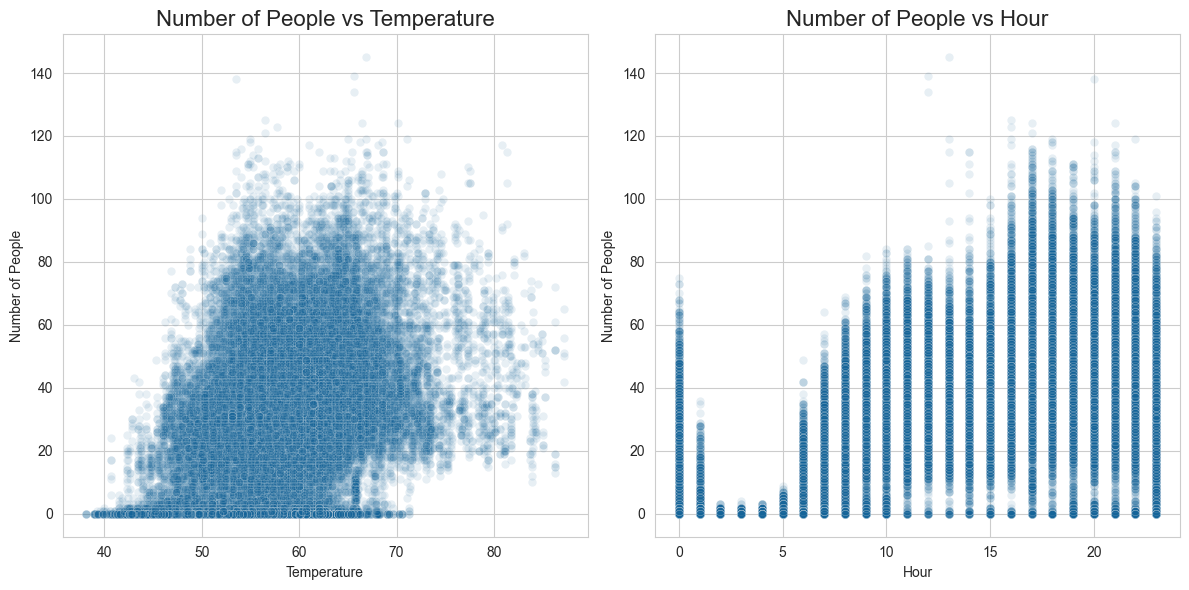

In [14]:
numerical_features = ["temperature", "hour"]

plt.figure(figsize=(12, 6))

for i, feature in enumerate(numerical_features):
    plt.subplot(1, 2, i+1)
    sns.scatterplot(x=gym_data[feature], y=gym_data["number_people"], color="#146499", alpha=0.1)
    plt.title(f"Number of People vs {feature.title()}", fontsize=16)
    plt.xlabel(feature.title())
    plt.ylabel("Number of People")

plt.tight_layout()
plt.show()

We indeed see evidence of a relationship between the number of people and temperature: more people tend to be in the gym when the temperature is mild to warm.

We also see evidence of a relationship between the number of people and hour of the day: 

* There are consistently very few people in the gym between 2am and 5am

* The largest peaks in number of people tend to occur during the early afternoon and into the evening.

* There is a somewhat surprisingly large peak number of gym-goers at midnight (hour 0), indicating there is a portion of the student body that may routinely attend the gym in the middle of the night.

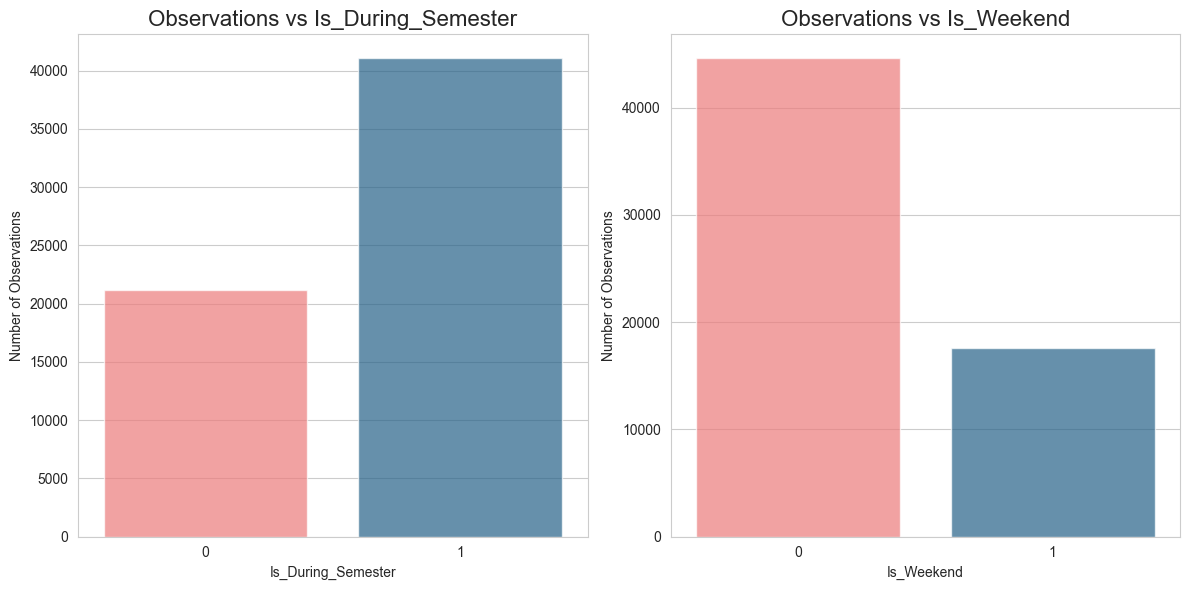

In [15]:
gym_data_grouped_semester = gym_data.groupby("is_during_semester")["number_people"].count().reset_index()
gym_data_grouped_weekend = gym_data.groupby("is_weekend")["number_people"].count().reset_index()

categorical_features = [gym_data_grouped_semester, gym_data_grouped_weekend]

plt.figure(figsize=(12, 6))

for i, feature in enumerate(categorical_features):
    plt.subplot(1, 2, i+1)
    sns.barplot(x=feature.columns[0], y=feature["number_people"], data=feature, palette="blend:#FF6868,#146499", alpha=0.7)
    plt.title(f"Observations vs {feature.columns[0].title()}", fontsize=16)
    plt.xlabel(feature.columns[0].title())
    plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

Finally, we illustrate the relationship between the number of people in the gym and the variables `is_during_semester` and `is_weekend`. In both cases, we can see a distinct different in the two classes: 

* There are roughly twice as many observations during the semester compared to dates outside of the semester.

* There are over double the number of observations made during weekdays compared to weekends.

## Model Fitting and Hyperparameter Optimization

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

y = gym_data["number_people"]
X = gym_data[["hour", "temperature", "is_weekend", "is_during_semester"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

grid_params = {
    'eta0': [1e-3],
    'tol': [1e-3],
    'learning_rate': ['optimal','adaptive'],
    'alpha': [1e-4, 0.001, 0.01],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'l1_ratio': [0.15, 0.5, 0.85],
    'loss': ['huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'],
    'epsilon': [0.001, 0.01, 0.1]
}

model = SGDRegressor(random_state=52)
model_grid = GridSearchCV(estimator=model, param_grid=grid_params, cv=5, n_jobs=-1, verbose=2)
model_grid.fit(X_train_scaled, y_train)

best_params = model_grid.best_params_
print("Best Hyperparameters:", best_params)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Best Hyperparameters: {'alpha': 0.001, 'epsilon': 0.01, 'eta0': 0.001, 'l1_ratio': 0.15, 'learning_rate': 'adaptive', 'loss': 'squared_epsilon_insensitive', 'penalty': 'elasticnet', 'tol': 0.001}


In [17]:
best_model = model_grid.best_estimator_

y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

## Model Version 1 Evaluation

In [18]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"""Train 
     
      RMSE: {train_rmse:.2f}
      MAE: {train_mae:.2f}
      R2: {train_r2:.3f}
      
==========================

Test 

      RMSE: {test_rmse:.2f}
      MAE: {test_mae:.2f}
      """)

Train 

      RMSE: 16.33
      MAE: 12.47
      R2: 0.482


Test 

      RMSE: 16.23
      MAE: 12.39
      


* An $R^{2}$ of 0.482 is satisfactory. The model is fit adequately to the training data.

* The training and testing error metrics (RMSE and MAE) are comparable in magnitude, implying the model has not been overfitted to the training data. This is the ideal scenario when creating a predictive model as we want the model to generalize well to unseen data.

## Visualizing the Difference between Actual and Predicted Values

A lineplot can be used to gain an insight into the difference. Model accuracy can be judged by assessing how much overlap exists between the actual and predicted lines.

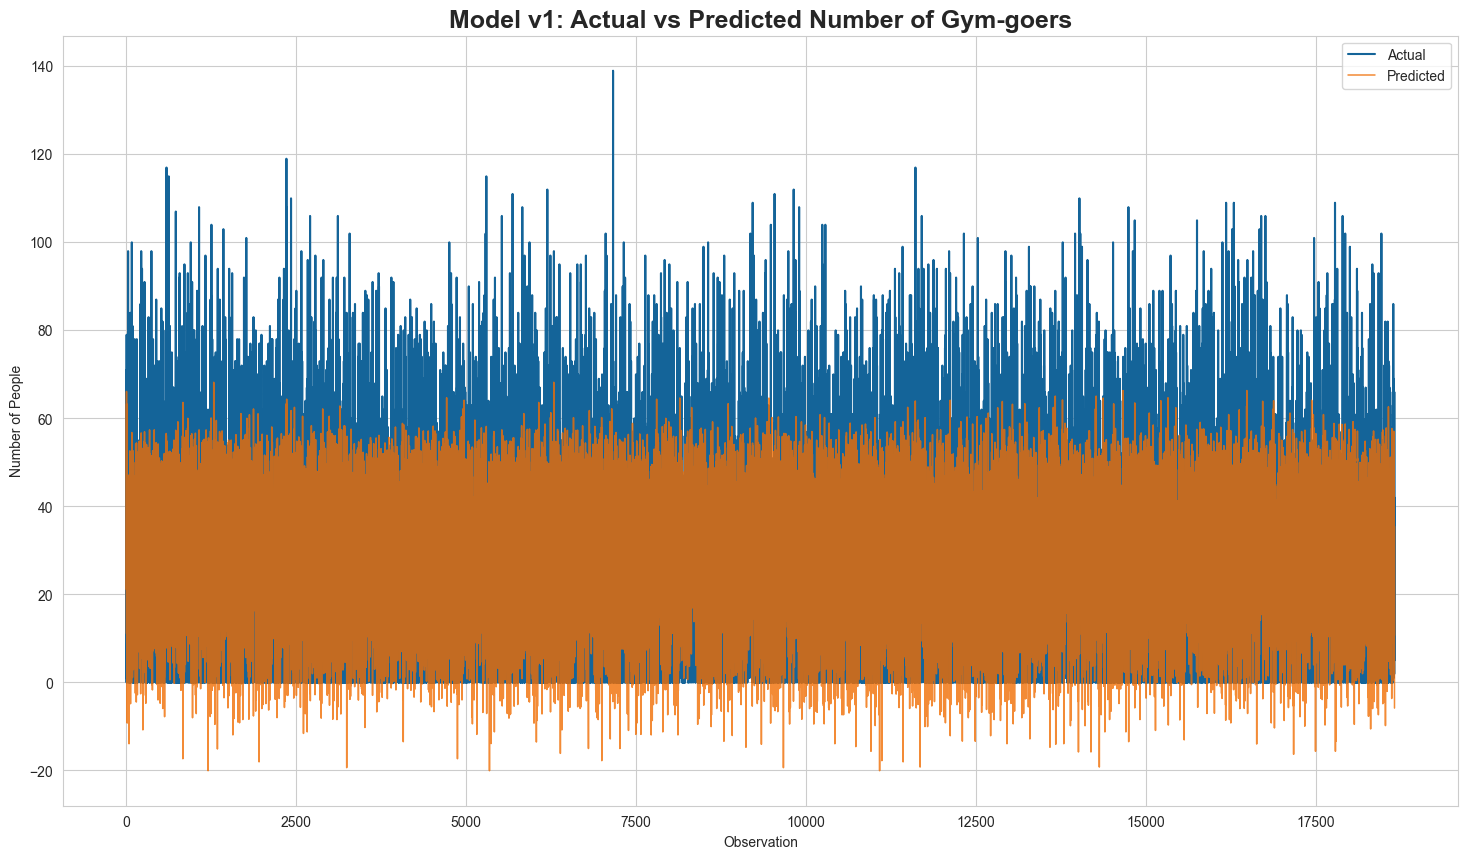

In [19]:
plt.figure(figsize=(18, 10))

x_ax = range(len(y_test))
sns.lineplot(x=x_ax, y=y_test, label="Actual", color="#146499")
sns.lineplot(x=x_ax, y=y_test_pred, label="Predicted", linewidth=1.1, color="#f06e04", alpha=0.8)
plt.title("Model v1: Actual vs Predicted Number of Gym-goers", weight="bold", fontsize=18)
plt.ylabel("Number of People")
plt.xlabel("Observation")

plt.show()

We see the model is performing adequately, but does seem to struggle at accurately predicting the number of gym-goers when the actual number exceeds 60 or so.

## Model Version 2

After the initial fitting and hyperparameter tuning using a grid search, we can turn to including additional features in the model to see if we can improve the model fit and lower the error metrics.

In [20]:
X = gym_data[["hour", "temperature", "is_weekend", "is_during_semester", "is_start_of_semester", "day_of_week", "month"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_v2 = SGDRegressor(alpha=0.001, epsilon=0.01, eta0=0.001, tol=0.001, l1_ratio=0.15, penalty="elasticnet", learning_rate="adaptive", loss="squared_epsilon_insensitive", random_state=52)
model_v2.fit(X_train_scaled, y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_epsilon_insensitive'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'elasticnet'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.01
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",52


In [21]:
y_train_pred = model_v2.predict(X_train_scaled)
y_test_pred = model_v2.predict(X_test_scaled)

In [22]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"""Train 
     
      RMSE: {train_rmse:.2f}
      MAE: {train_mae:.2f}
      R2: {train_r2:.3f}
      
==========================

Test 

      RMSE: {test_rmse:.2f}
      MAE: {test_mae:.2f}
      """)

Train 

      RMSE: 15.94
      MAE: 12.19
      R2: 0.506


Test 

      RMSE: 15.84
      MAE: 12.11
      


By introducing additional features `is_start_of_semester`, `day_of_week` and `month`, we **improve** the model fit compared to the first version: 

* $R^{2}$ increases from 0.482 to 0.506

* We observe a reduction in both error metrics (RMSE and MAE)

As a result, version 2 is an improvement upon version 1. 

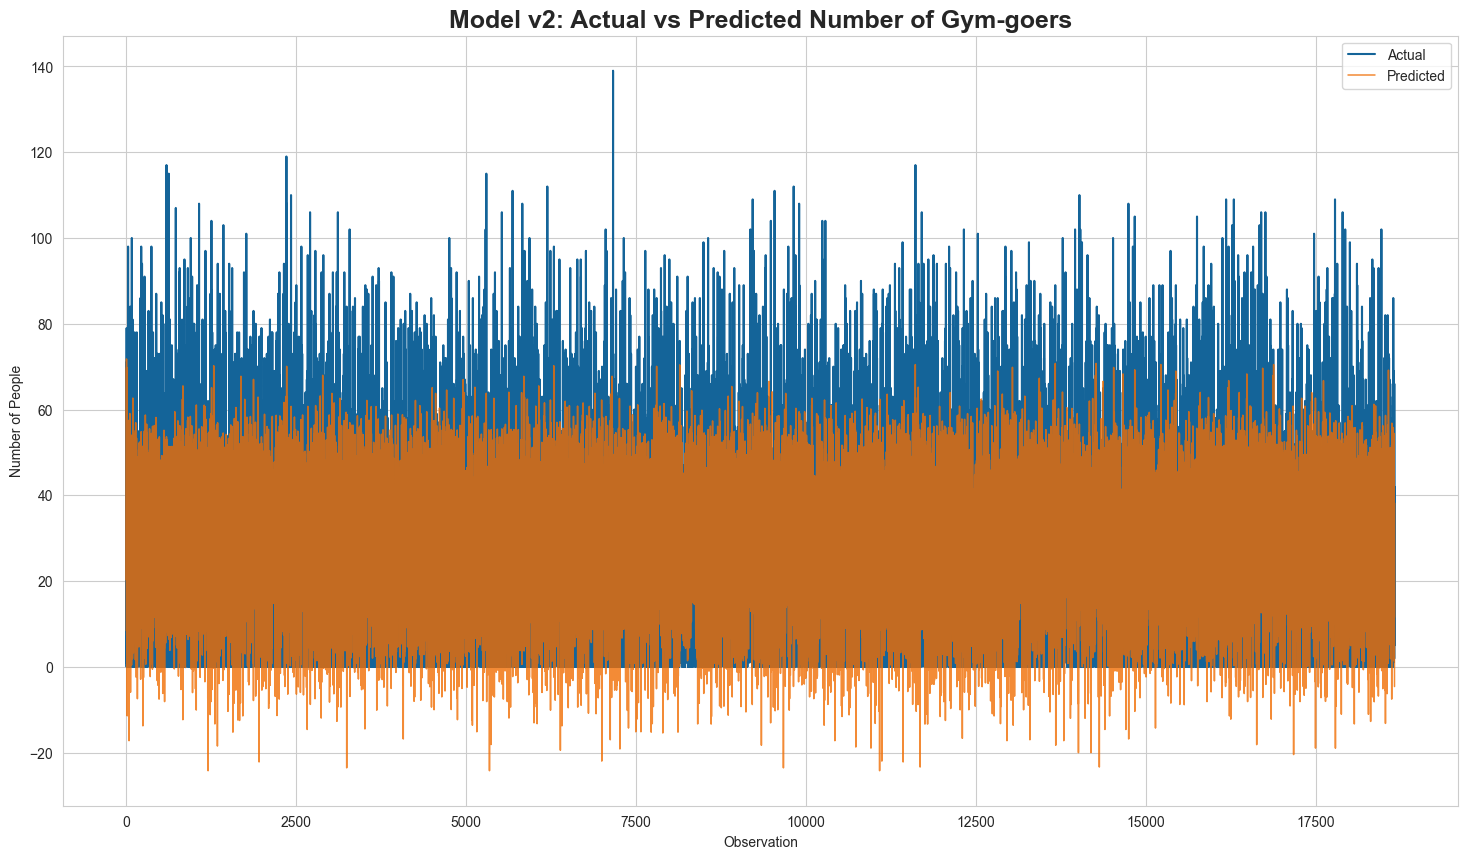

In [23]:
plt.figure(figsize=(18, 10))

x_ax = range(len(y_test))
sns.lineplot(x=x_ax, y=y_test, label="Actual", color="#146499")
sns.lineplot(x=x_ax, y=y_test_pred, label="Predicted", linewidth=1.1, color="#f06e04", alpha=0.8)
plt.title("Model v2: Actual vs Predicted Number of Gym-goers", weight="bold", fontsize=18)
plt.ylabel("Number of People")
plt.xlabel("Observation")

plt.show()

Comparing this plot to the version 1 plot, we can see a *slight* improvement. Version 2 of the model does improve its accuracy when the actual number of gym-goers exceeds 60. We can see spikes in the predicted values above 60 in these cases where we did not in the previous version of the model.

To gain a clearer insight into what the above plot represents, we can plot a sample of the observations for better visibility:

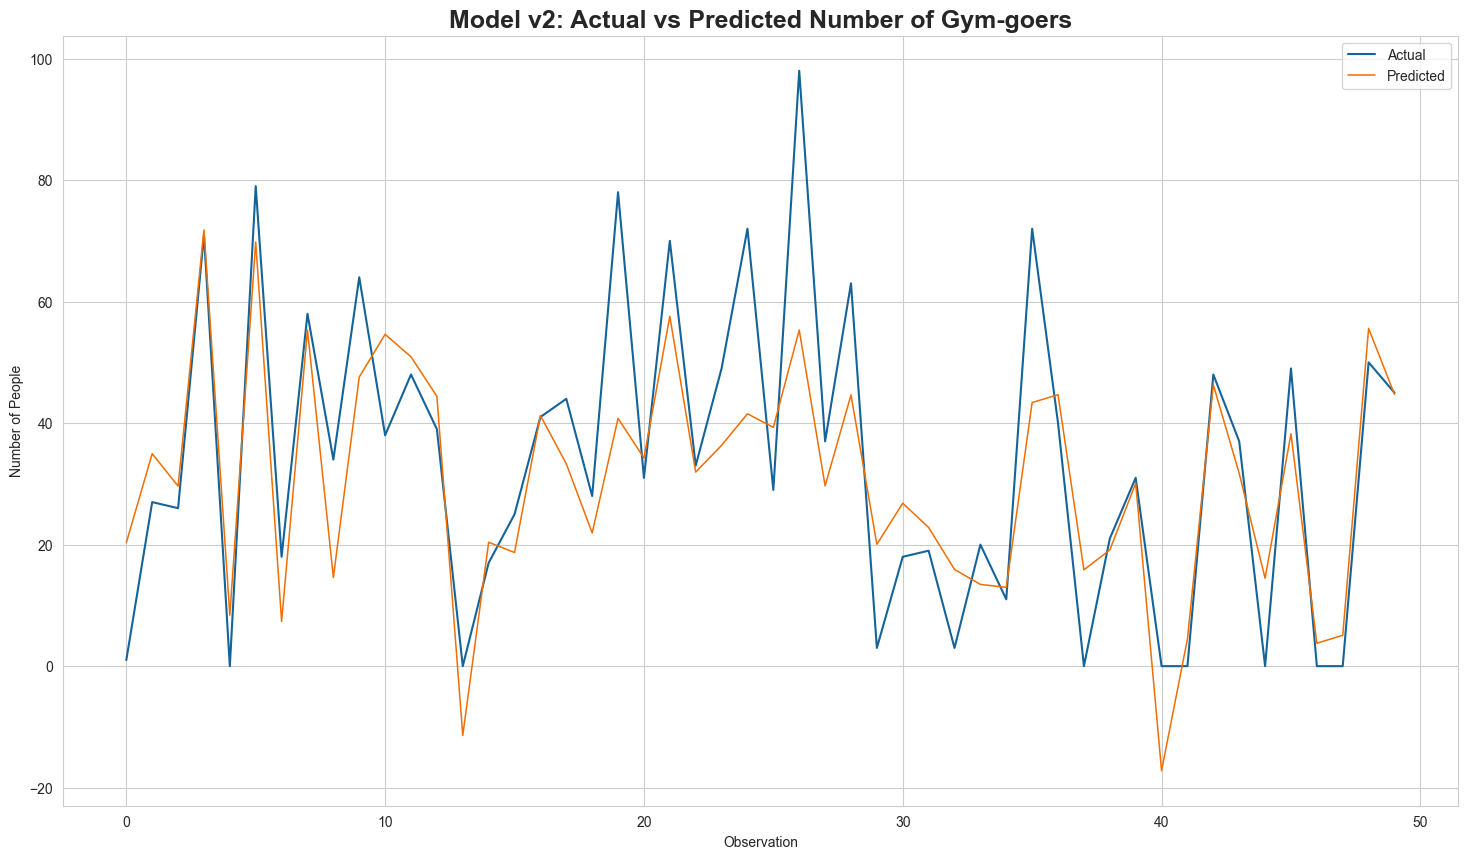

In [24]:
plt.figure(figsize=(18, 10))

x_ax = range(50) # only plot the first 50 observations for better visibility
sns.lineplot(x=x_ax, y=y_test[:50], label="Actual", color="#146499")
sns.lineplot(x=x_ax, y=y_test_pred[:50], label="Predicted", linewidth=1.1, color="#f06e04")
plt.title("Model v2: Actual vs Predicted Number of Gym-goers", weight="bold", fontsize=18)
plt.ylabel("Number of People")
plt.xlabel("Observation")

plt.show()

We can see the predicted values generally agree with the actual values for each observation, with some deviation. Overall, the accuracy seems reasonable and fit for purpose (we do not require the model to be exceptionally accurate).

Some of the predicted values are less than zero. We can investigate this:

In [25]:
predicted_vs_actual = pd.DataFrame({"Predicted": y_test_pred, "Actual": y_test.values})
predicted_vs_actual[predicted_vs_actual["Predicted"] < 0].head(10)

,Predicted,Actual
13,-11.411913,0
40,-17.210563,0
62,-5.904239,0
147,-2.429798,1
163,-7.424404,0
211,-2.884858,0
244,-13.749264,0
253,-2.475062,0
352,-2.258047,0
384,-0.533401,0


In [26]:
predicted_vs_actual[predicted_vs_actual["Predicted"] < 0]["Actual"].value_counts() # check the actual values for the cases where the model predicted negative gym-goers

Actual
0     502
1     115
2      21
17      7
3       7
13      5
10      5
15      4
4       4
7       4
5       4
16      3
9       3
14      2
11      2
8       2
6       2
23      2
19      2
21      1
12      1
20      1
18      1
Name: count, dtype: int64

Since the vast majority of these negative predictions correspond to zero, one or two gym-goers, it is reasonable to take a negative predicted value to mean there are likely no (or very few) people in the gym at these times.

### Concluding Remarks

* Model v2 is an improvement upon v1, though it is important to note that the quality of v2 could certainly still be improved as an $R^{2}$ value of 0.506 is not remarkably strong. With regards to the predictive power of v2, we can conclude the model is not overfitting the training data since both training and testing error metrics (RMSE and MAE) are comparable in magnitude. This suggests the model is generalizing as well as it can.

* There are some observations that return negative values for the predicted number of people in the gym. This clearly does not make sense, it is a result of the regression line not being restricted to predict values of zero or above. This is not actually a huge issue since the vast majority of negative predicted values correspond to times where there are zero or one person in the gym, meaning a negative predicted value can be taken to mean there are no people (or very few) in the gym.

* Looking at the testing RMSE value for version 2 of the model, a value of 15.84 suggests on average, the predicted number of gym-goers as calculated by the model from the inputted features is off by 15.84 (~16) people when compared to the true value. Since RMSE is sensitive to outliers, this means that the accuracy of the model on the whole is pretty good.

* The model is not perfect, there may be times where a prediction is off by a number exceeding 16, but considering how this model is going to be used, this seems to be an acceptable level of error. For example, it is not the end of the world if you arrive at the gym expecting only 25 people to be there, but you instead find there are 50.

#### Model v2

In [27]:
model_v2.intercept_, model_v2.coef_

(array([29.15043446]),
 array([11.19723989,  5.42873822, -2.50508362,  5.97773243,  1.82116651,
        -1.6323283 , -2.60533863]))

The final linear regression line for the chosen features is given below. The intercept and coefficients were determined using stochastic gradient descent, minimizing the `squared_epsilion_insensitive` loss function (L2 loss) used in **support vector regression** (SVR).
$$
N_{gym} = 29.15 + 11.20(hour) + 5.43(temperature) - 2.51(weekend) + 5.98(duringsemester) + 1.82(startsemester) - 1.63(dayofweek) - 2.61(month)
$$

Note, the coefficients should not be interpreted as there is strong collinearity between the explanatory variables. The intercept also does not have any real meaning.

In [28]:
test = [12, 67, 0, 1, 0, 3, 5] # hour=12, temperature=67, is_weekend=0, is_during_semester=1, is_start_of_semester=0, day_of_week=3 (Wednesday), month=5 (May)
test_scaled = scaler.transform([test])

prediction = int(model_v2.predict(test_scaled).round(0).reshape(-1)[0])

prediction

43